# Lab: Weighing a Supermassive Black Hole

**Inspired by the 2020 Nobel Prize in Physics awarded to Andrea Ghez and Reinhard Genzel**

The Nobel Prize in Physics will be awarded on October 7, 2025 (P.S. My guess is something related to Quantum Information Theory). Let's look back at a prize from a few years ago.

First go to this video: https://www.youtube.com/watch?v=6B3P7o8QMz8 (note, it was filmed and released prior to the Andrea Ghez winning the Nobel Prize).

---

### Objective
In this lab, you will use real observational data of a star (S0-2) orbiting the center of the Milky Way to calculate the mass of the supermassive black hole, Sagittarius A* (Sgr A*). You will apply the **Momentum Principle** to infer the gravitational force on the star from its motion.

---

### Background
For decades, astronomers suspected a supermassive black hole (SMBH) lurked at the center of our galaxy. The challenge was proving it. Since a black hole emits no light, we can only detect it by its gravitational influence on nearby objects. Andrea Ghez and her team at UCLA spent years meticulously tracking the positions of stars orbiting the galactic center.

By observing the complete orbit of a star, S0-2, they were able to show that it must be orbiting an incredibly massive and compact object. The only known object that fits this description is a black hole. Their analysis, which you will replicate today, provides the most compelling evidence for the existence of Sgr A* and allowed them to calculate its mass.

The core physical idea is the link between motion and force. The Momentum Principle in its discrete form states:

$$ \vec{F}_{\text{net}} = \frac{\Delta \vec{p}}{\Delta t} = \frac{\vec{p}_f - \vec{p}_i}{\Delta t} $$

Where $\vec{p} = m\vec{v}$ is the momentum. If we know the position of an object at different times, we can calculate its velocity, then its momentum, and finally the net force that must have caused that change in momentum.

Since the dominant force on the star is the gravity from the black hole, we have:

$$ |\vec{F}_{\text{net}}| \approx |\vec{F}_{\text{gravity}}| = G \frac{M_{\text{BH}} m_{\text{star}}}{r^2} $$

By calculating $|\vec{F}_{\text{net}}|$ from the star's motion and measuring the distance $r$, we can solve for the mass of the black hole, $M_{\text{BH}}$.

---

### Procedure

#### 1. The Data
You will use actual data for the star S0-2, provided by the UCLA Galactic Center Group. The data contains the year of observation and the star's position in right ascension (x) and declination (y), measured in arcseconds.

For convenience, here is a subset of the data


In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
# Data for S0-2 Orbit
# Source: UCLA Galactic Center Group / W. M. Keck Observatory
# Columns: Year, RA_offset (arcsec), Dec_offset (arcsec),RA_err,Dec_Err

s02_data_string = """
1995.524   -0.1252   -0.1832    0.0005      0.0005
1996.265   -0.1084   -0.1691    0.0005      0.0005
1996.429   -0.1017   -0.1659    0.0005      0.0005
1997.465   -0.0769   -0.1479    0.0005      0.0005
1998.262   -0.0544   -0.1311    0.0004      0.0004
1999.428   -0.0210   -0.1064    0.0004      0.0004
2000.481    0.0163   -0.0768    0.0004      0.0004
2001.505    0.0519   -0.0463    0.0004      0.0004
2002.532    0.0818   -0.0076    0.0003      0.0003
2003.521    0.1018    0.0298    0.0003      0.0003
2004.507    0.1118    0.0628    0.0003      0.0003
2005.548    0.1130    0.0911    0.0003      0.0003
2006.562    0.1072    0.1147    0.0003      0.0003
2007.550    0.0968    0.1341    0.0003      0.0003
2008.537    0.0827    0.1492    0.0003      0.0003
2009.580    0.0655    0.1607    0.0004      0.0004
2010.556    0.0468    0.1687    0.0004      0.0004
2011.589    0.0255    0.1733    0.0004      0.0004
2012.583    0.0028    0.1748    0.0004      0.0004
2013.621   -0.0207    0.1729    0.0004      0.0004
2014.348   -0.0407    0.1690    0.0004      0.0004
2015.556   -0.0664    0.1603    0.0004      0.0004
2016.592   -0.0917    0.1465    0.0004      0.0004
2017.584   -0.1187    0.1246    0.0004      0.0004
2018.330   -0.1360    0.0905    0.0003      0.0003
2018.411   -0.1364    0.0824    0.0003      0.0003
2018.575   -0.1363    0.0645    0.0003      0.0003
2019.468   -0.1306    0.0263    0.0004      0.0004
2020.528   -0.1183   -0.0175    0.0004      0.0004
2021.430   -0.1052   -0.0553    0.0005      0.0005
2022.460   -0.0855   -0.0921    0.0005      0.0005
"""
data = np.loadtxt(io.StringIO(s02_data_string))

#### 2. Setup and Constants
First, let's set up our Python environment and define the necessary physical constants and conversion factors.

```python
# --- Physical Constants ---
G = 6.6743e-11  # Gravitational constant (N m^2 / kg^2)
M_SOLAR = 1.989e30  # Mass of the Sun (kg)
m_star = 15 * M_SOLAR # Approximate mass of S0-2 (15 solar masses)

# --- Conversion Factors ---
YEAR_TO_SEC = 3.154e7   # Seconds in a year
ARCSEC_TO_RAD = 4.848e-6 # Radians in an arcsecond
# Distance from Earth to the Galactic Center (meters)
# Approx 8,277 parsecs or 26,980 light-years
D_GC = 2.55e20

# --- Function to convert angular position (arcsec) to physical position (m) ---
def arcsec_to_meter(angle_arcsec):
    """Converts an angular size in arcseconds to a physical size in meters."""
    angle_rad = angle_arcsec * ARCSEC_TO_RAD
    return angle_rad * D_GC

In [ ]:
# --- Physical Constants ---
G = 6.6743e-11  # Gravitational constant (N m^2 / kg^2)
M_SOLAR = 1.989e30  # Mass of the Sun (kg)
m_star = 15 * M_SOLAR # Approximate mass of S0-2 (15 solar masses)

# --- Conversion Factors ---
YEAR_TO_SEC = 3.154e7   # Seconds in a year
ARCSEC_TO_RAD = 4.848e-6 # Radians in an arcsecond
# Distance from Earth to the Galactic Center (meters)
# Approx 8,277 parsecs or 26,980 light-years
D_GC = 2.55e20

# --- Function to convert angular position (arcsec) to physical position (m) ---
def arcsec_to_meter(angle_arcsec):
    """Converts an angular size in arcseconds to a physical size in meters."""
    angle_rad = angle_arcsec * ARCSEC_TO_RAD
    return angle_rad * D_GC

#### 3. Load and Prepare Data
Now load the data and convert the units from years and arcseconds to seconds and meters.



In [ ]:
# --- Load and Process Data ---
# Load data from the text file
# Columns: 0=Year, 1=RA (x), 2=Dec (y)
# Convert time to seconds, shifting the start time to t=0

time_yr = data[:, 0]
time_s = time_yr * YEAR_TO_SEC

# Convert angular positions to meters
# We assume the black hole is at (0,0)
pos_x_m = arcsec_to_meter(data[:, 1])
pos_y_m = arcsec_to_meter(data[:,2])

# Combine into a position vector array
# pos[i] is the vector (x_i, y_i)
pos = np.array([pos_x_m, pos_y_m]).T

#### 4. Calculate Velocity and Force using the Momentum Principle ---
This is the core of the lab. We cannot know the instaneous velocity at each point, so we must approximate it. We will use the central difference method, which calculates the average velocity between two points in time t_i and t_i{i+1}. This gives us the velocity at the midpoint in time.

$$v_{\textrm{avg}}(t_{i}+\frac{\Delta t}{2})\approx\frac{r_{i+1}-r_{i}}{t_{i+1}-t_{i}}$$

We can then use these average velocities to find the change in momentum, and subsequently, the net force.




In [ ]:

# We need to loop from the first to the second-to-last point to calculate differences
num_points = len(time_yr)
velocities = []
momenta = []
forces = []
force_positions = [] # Position where the force is calculated
time_midpoints = []   # Time at which the force is calculated

# Calculate average velocities between points
for i in range(num_points - 1):
  dr = pos[i+1] - pos[i]
  velocities.append(dr / (time_s[i+1] - time_s[i]))
  momenta.append(m_star * velocities[i])

# Now, calculate the force using the change in momentum
# The force is calculated at the time of the middle data point
for i in range(len(velocities) - 1):
    # Time interval over which the momentum changes
    # This is the time from the midpoint of (t_i, t_{i+1}) to (t_{i+1}, t_{i+2})
    dt = 0.25 * (time_s[i] + 2*time_s[i+1] + time_s[i+2])
    time_midpoints.append(time_s[i+1])
    force_positions.append(pos[i+1])
    # Change in momentum
    dp = (momenta[i+1] - momenta[i])

    # Force from Momentum Principle
    forces.append(dp/dt)

    # This force corresponds to the position and time of the middle point


# Convert lists to numpy arrays for easier calculations
forces = np.array(forces)
force_positions = np.array(force_positions)

#### 5.Visualize the Orbit and Forces
 A great way to check our work is to plot the orbit and draw the calculated force vectors at each point. If we've done this correctly, all the force vectors should point towards the center of the orbit (0,0), where the black hole is!

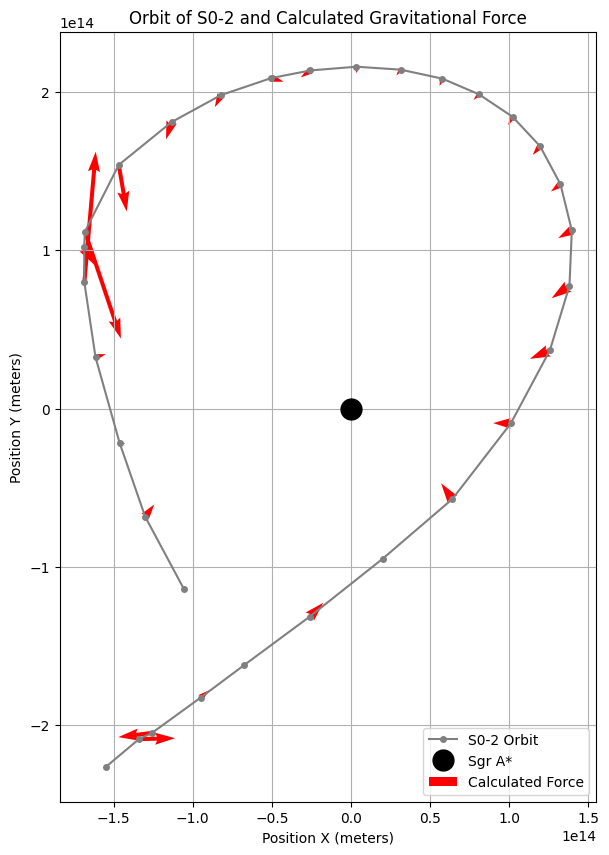

In [ ]:
# --- Plot the Orbit and Force Vectors ---
plt.figure(figsize=(10, 10))
# Plot the orbit
plt.plot(pos[:, 0], pos[:, 1], 'o-', label='S0-2 Orbit', markersize=4, c='gray')
# Plot the black hole at the center
plt.plot(0, 0, 'o', markersize=15, color='black', label='Sgr A*')

# Add the force vectors
# We use a 'quiver' plot for vectors
plt.quiver(force_positions[:, 0], force_positions[:, 1], # Vector start points
           forces[:, 0], forces[:, 1],                   # Vector components
           color='red', scale=5e27, label='Calculated Force') # Scale down vectors for plotting

plt.title("Orbit of S0-2 and Calculated Gravitational Force")
plt.xlabel("Position X (meters)")
plt.ylabel("Position Y (meters)")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True)
plt.show()

#### 6. Calculate the Black Hole Mass

Now for the final step. We will test the inverse-square law relationship. We expect:

$$|F_{\textrm{net}}|=\frac{GM_{\textrm{BH}}m_{\textrm{star}}}{r^{2}}$$

Black Hole Mass:  3.653427968880788e+32 kg
This is  183.68 solar masses


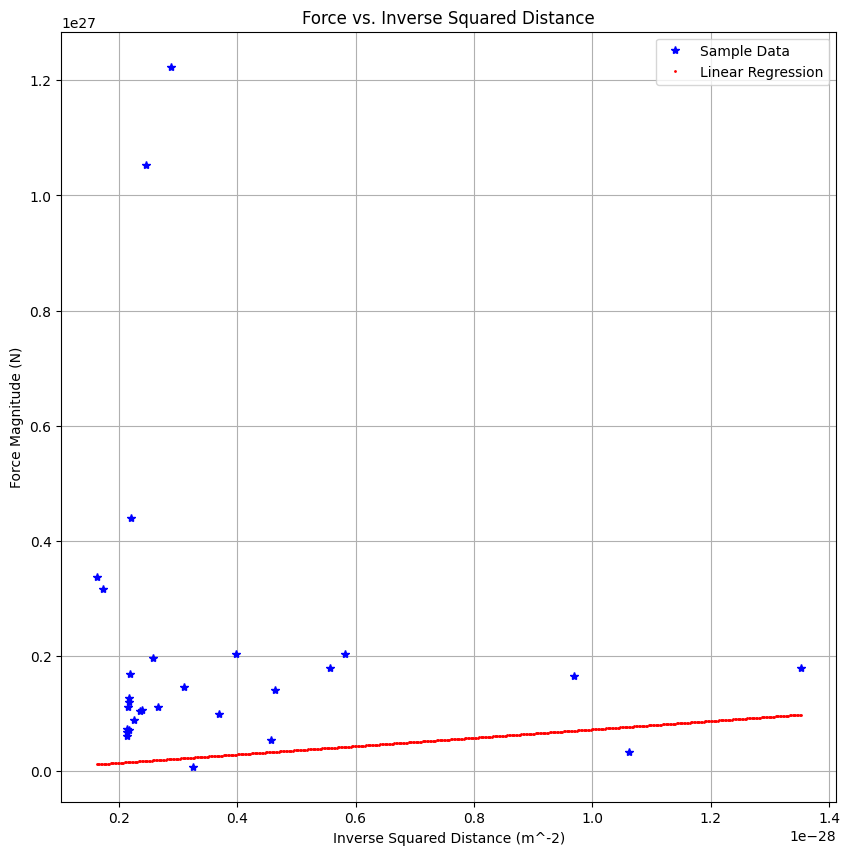

In [ ]:
# --- Analyze the Force vs. Distance Relationship ---

# Calculate the magnitude of the force vectors
mag_forces = []
for force in forces:
  mag_forces.append(np.linalg.norm(force))
mag_forces = np.array(mag_forces)

# Calculate the distance (r) from the black hole for each force point
mag_pos = []
for i in range(1, len(pos) - 1):
  mag_pos.append(np.linalg.norm(pos[i]))
mag_pos = np.array(mag_pos)

# We need 1/r^2 for our linear fit
one_over_r_squared = []
for magPos in mag_pos:
  one_over_r_squared.append(magPos ** (-2))
one_over_r_squared = np.array(one_over_r_squared)

# --- Perform a linear regression (fit a line) ---
# linregress returns: slope, intercept, r_value, p_value, std_err
# for example
m, b = np.polyfit(one_over_r_squared, mag_forces, 1)

# --- Calculate the Mass of the Black Hole ---
# slope = G * M_BH * m_star  =>  M_BH = slope / (G * m_star)
# below


# --- Plot the linear fit ---
plt.figure(figsize=(10,10))
plt.plot(one_over_r_squared[:], mag_forces[:], '*', label = "Sample Data", color = "blue")
samplePoints = np.linspace(min(one_over_r_squared), max(one_over_r_squared), num = 500)
last = b + m*samplePoints[-1]
M = last / samplePoints[-1]
M_BH = M / (G * m_star)
print("Black Hole Mass: ", round(M_BH, 5), "kg")
print("This is ", round(M_BH / M_SOLAR, 2), "solar masses")

plt.plot(samplePoints[:], M * samplePoints[:], "o", label = "Linear Regression", markersize = 1, color = "red")
plt.xlabel("Inverse Squared Distance (m^-2)")
plt.ylabel("Force Magnitude (N)")
plt.title("Force vs. Inverse Squared Distance")
plt.legend()
plt.grid(True)
plt.show()

####Questions



1.    What value did you calculate for the mass of Sagittarius A* in millions of solar masses? The currently accepted value is approximately 4.3 million solar masses. How does your result compare?
2.   Look at your plot of the orbit and force vectors. In which direction do the force vectors point? Does this make physical sense? Why?
3.   What are some assumptions we made in this model that could lead to errors in our final calculation? (Hint: Think about other objects in the galaxy, the mass of S0-2, and the measurement data itself).
4.   We inferred the force from the motion. Describe how you could work in the other direction. If you assumed a mass for the black hole, how could you use an integrator (like Euler-Cromer) and the Law of Universal Gravitation to predict the star's orbit? How could you use that prediction to see if your assumed mass was correct?


